# **1. Configuración del Entorno e Instalación de Dependencias**

In [ ]:
# --- INSTALACIÓN DE DEPENDENCIAS ---
print("[INFO] Instalando librerías necesarias...")
!pip install -q segmentation-models albumentations==1.3.1 streamlit pyngrok > /dev/null

# Configuración de variables de entorno para compatibilidad
import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'

print("[SUCCESS] Entorno configurado correctamente.")

[INFO] Instalando librerías necesarias...
[SUCCESS] Entorno configurado correctamente.


# **2: Gestión de Datos (Carga y Descompresión)**

In [ ]:
import os
import shutil
import zipfile
from google.colab import drive

# --- CONFIGURACIÓN ---
RAR_NAME = "Refuge.rar"
DRIVE_BASE = "/content/drive/MyDrive/TFG_Glaucoma"
DRIVE_PATH = os.path.join(DRIVE_BASE, RAR_NAME)
LOCAL_ZIP = f"/content/{RAR_NAME}"
EXTRACT_PATH = "/content/dataset_local"

def setup_data():
    # 1. Conectar Drive
    if not os.path.exists('/content/drive'):
        print("[INFO] Conectando Google Drive...")
        drive.mount('/content/drive')

    # 2. Verificar origen
    if not os.path.exists(DRIVE_PATH):
        print(f"[ERROR] No se encuentra el archivo {RAR_NAME} en {DRIVE_BASE}")
        return

    # 3. Copia local (Optimización de I/O)
    if not os.path.exists(LOCAL_ZIP):
        print(f"[INFO] Copiando {RAR_NAME} al entorno local...")
        shutil.copy(DRIVE_PATH, LOCAL_ZIP)

    # 4. Descompresión
    if not os.path.exists(EXTRACT_PATH):
        print("[INFO] Instalando utilidades de descompresión...")
        os.system('apt-get install unrar > /dev/null')

        print("[INFO] Descomprimiendo dataset principal...")
        os.makedirs(EXTRACT_PATH, exist_ok=True)
        os.system(f'unrar x -o+ "{LOCAL_ZIP}" "{EXTRACT_PATH}" > /dev/null')

    # 5. Gestión de Máscaras Anidadas
    masks_zip_path = os.path.join(EXTRACT_PATH, 'Refuge', 'Annotation-Training400', 'Disc_Cup_Masks.zip')
    masks_target_dir = os.path.join(EXTRACT_PATH, 'Refuge', 'Annotation-Training400', 'Disc_Cup_Masks')

    if os.path.exists(masks_zip_path):
        print("[INFO] Descomprimiendo máscaras anidadas...")
        with zipfile.ZipFile(masks_zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.dirname(masks_zip_path))
        print("[SUCCESS] Máscaras extraídas correctamente.")
    elif os.path.exists(masks_target_dir):
        print("[INFO] Las máscaras ya están descomprimidas.")
    else:
        print("[WARNING] No se encontró el ZIP de máscaras ni la carpeta destino.")

    print("[SUCCESS] Carga de datos completada.")

if __name__ == "__main__":
    setup_data()

[INFO] Conectando Google Drive...
Mounted at /content/drive
[INFO] Copiando Refuge.rar al entorno local...
[INFO] Instalando utilidades de descompresión...
[INFO] Descomprimiendo dataset principal...
[INFO] Las máscaras ya están descomprimidas.
[SUCCESS] Carga de datos completada.


# **CÓDIGO DE ENTRENAMIENTO (MODELOS YA ENTRENADOS)**

In [ ]:
import os
import glob
import cv2
import gc
import random
import numpy as np
import tensorflow as tf
import albumentations as A
import segmentation_models as sm
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass
from sklearn.model_selection import KFold
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau,
    CSVLogger, TensorBoard
)

# --- 1. CONFIGURACIÓN CENTRALIZADA ---
@dataclass
class Config:
    SEED: int = 42
    IMG_SIZE: int = 512
    BATCH_SIZE: int = 8      # Subir a 16 si usas A100. 8 es seguro para T4/L4.
    EPOCHS: int = 50
    BACKBONE: str = 'inceptionresnetv2'
    N_SPLITS: int = 5
    CLASSES: int = 3         # 0: Fondo, 1: Disco, 2: Copa
    LR_START: float = 1e-4
    BASE_PATH: str = "/content/dataset_local/Refuge"
    SAVE_PATH: str = "/content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed"

# Crear directorios
os.makedirs(Config.SAVE_PATH, exist_ok=True)
os.makedirs(os.path.join(Config.SAVE_PATH, 'logs'), exist_ok=True)

# --- 2. ENTORNO & MIXED PRECISION ---
def set_environment(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Activar Mixed Precision (Velocidad x2, menos VRAM)
    try:
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"⚡ Mixed Precision Activado: {policy.compute_dtype}")
    except:
        print("⚠️ No se pudo activar Mixed Precision. Usando float32 estándar.")

    print(f"🌱 Semilla Global Fijada: {seed}")

set_environment(Config.SEED)

# --- 3. FUNCIONES AUXILIARES PARA MIXED PRECISION (FIX DEFINITIVO) ---

def cast_f32(t):
    return tf.cast(t, tf.float32)

# 1. Instanciamos los objetos de métrica y pérdida FUERA de las funciones.
#    El 'threshold' se configura aquí, una sola vez.
IOU_METRIC_OBJ = sm.metrics.IOUScore(threshold=0.5)
DICE_LOSS_OBJ = sm.losses.DiceLoss()
FOCAL_LOSS_OBJ = sm.losses.CategoricalFocalLoss()

# 2. Wrappers que usan los objetos pre-configurados
def dice_coef_disc(y_true, y_pred):
    # Usamos el objeto instanciado arriba
    return IOU_METRIC_OBJ(cast_f32(y_true[..., 1]), cast_f32(y_pred[..., 1]))

def dice_coef_cup(y_true, y_pred):
    return IOU_METRIC_OBJ(cast_f32(y_true[..., 2]), cast_f32(y_pred[..., 2]))

def global_iou(y_true, y_pred):
    # Ya no pasamos threshold aquí, porque IOU_METRIC_OBJ ya lo tiene configurado
    return IOU_METRIC_OBJ(cast_f32(y_true), cast_f32(y_pred))

def hybrid_loss(y_true, y_pred):
    y_true_f = cast_f32(y_true)
    y_pred_f = cast_f32(y_pred)

    # Llamamos a los objetos globales (más rápido y sin errores de instanciación)
    dice = DICE_LOSS_OBJ(y_true_f, y_pred_f)
    focal = FOCAL_LOSS_OBJ(y_true_f, y_pred_f)

    return dice + focal

# --- EL RESTO DEL CÓDIGO (DATA PIPELINE, ETC.) SIGUE IGUAL ---
# Asegúrate de usar estas funciones 'global_iou', 'hybrid_loss', etc.
# en el model.compile() más abajo.

# --- 4. PIPELINE DE DATOS (tf.data) ---
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.8),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
        A.OpticalDistortion(distort_limit=0.2, p=0.5),
    ], p=0.5),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.2),
])

def load_data_wrapper(image_path, mask_path, augment=False):
    """Carga, Recorta (ROI), Preprocesa y Aumenta"""
    image_path = image_path.decode('utf-8')
    mask_path = mask_path.decode('utf-8')

    # 1. Leer
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # 2. ROI Crop (Lógica del Glaucoma)
    g = img[:,:,1]
    blur = cv2.GaussianBlur(g, (41,41), 0)
    maxLoc = cv2.minMaxLoc(blur)[3]
    cx, cy = maxLoc
    h, w, _ = img.shape
    x1, y1 = max(0, cx-200), max(0, cy-200)
    x2, y2 = min(w, cx+200), min(h, cy+200)

    img = img[y1:y2, x1:x2]
    mask = mask[y1:y2, x1:x2]

    # 3. Resize
    img = cv2.resize(img, (Config.IMG_SIZE, Config.IMG_SIZE))
    mask = cv2.resize(mask, (Config.IMG_SIZE, Config.IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # 4. Procesar Máscara (Lógica REFUGE blanco/negro)
    new_mask = np.zeros_like(mask, dtype=np.float32)
    if mask[0,0] > 200: # Fondo blanco
        new_mask[(mask > 100) & (mask < 200)] = 1
        new_mask[mask < 100] = 2
    else: # Fondo negro
        new_mask[(mask > 100) & (mask < 200)] = 1
        new_mask[mask > 200] = 2

    # 5. Augmentation
    if augment:
        try:
            aug = train_transform(image=img, mask=new_mask)
            img, new_mask = aug['image'], aug['mask']
        except: pass

    # 6. Preprocessing Backbone
    preprocess_input = sm.get_preprocessing(Config.BACKBONE)
    img = preprocess_input(img)

    # 7. One Hot
    new_mask = tf.keras.utils.to_categorical(new_mask, num_classes=Config.CLASSES)

    return img.astype(np.float32), new_mask.astype(np.float32)

def create_dataset(pairs, augment=False):
    img_paths, mask_paths = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(img_paths), list(mask_paths)))

    ds = ds.map(
        lambda x, y: tf.numpy_function(
            func=load_data_wrapper,
            inp=[x, y, augment],
            Tout=[tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Fijar formas es OBLIGATORIO tras numpy_function
    ds = ds.map(lambda x, y: (tf.ensure_shape(x, [Config.IMG_SIZE, Config.IMG_SIZE, 3]),
                              tf.ensure_shape(y, [Config.IMG_SIZE, Config.IMG_SIZE, Config.CLASSES])))

    if augment:
        ds = ds.shuffle(buffer_size=200, seed=Config.SEED)

    ds = ds.batch(Config.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# --- 5. BÚSQUEDA DE ARCHIVOS: SPLIT ESTRICTO TRAIN / VALIDACIÓN EXTERNA ---

def get_all_pairs_robust(dirs_list):
    """
    Indexa pares imagen-máscara de forma robusta.

    Devuelve:
        np.array con tuplas (ruta_imagen, ruta_mascara)
    """
    all_pairs = []
    print("🔍 Indexando dataset...")

    for img_d, msk_d in dirs_list:
        if not os.path.exists(img_d):
            print(f"⚠️ Carpeta de imágenes no encontrada: {img_d}")
            continue

        if not os.path.exists(msk_d):
            print(f"⚠️ Carpeta de máscaras no encontrada: {msk_d}")
            continue

        img_paths = sorted(
            glob.glob(os.path.join(img_d, '**', '*.jpg'), recursive=True)
        )

        msk_files = (
            glob.glob(os.path.join(msk_d, '**', '*.bmp'), recursive=True)
            + glob.glob(os.path.join(msk_d, '**', '*.png'), recursive=True)
        )

        msk_map = {
            os.path.basename(f).split('.')[0]: f
            for f in msk_files
        }

        for img_p in img_paths:
            base = os.path.basename(img_p).split('.')[0]
            found_mask = None

            # Coincidencia directa
            if base in msk_map:
                found_mask = msk_map[base]

            # Coincidencia parcial, por si la máscara tiene sufijos
            else:
                for k, v in msk_map.items():
                    if base in k or k in base:
                        found_mask = v
                        break

            if found_mask is not None:
                all_pairs.append((img_p, found_mask))
            else:
                print(f"⚠️ No se encontró máscara para: {base}")

    return np.array(all_pairs)


# Dataset usado para entrenar y validar internamente los folds
TRAIN_DIRS = [
    (
        os.path.join(Config.BASE_PATH, 'REFUGE-Training400', 'Training400'),
        os.path.join(Config.BASE_PATH, 'Annotation-Training400', 'Disc_Cup_Masks')
    )
]

# Dataset reservado exclusivamente para evaluación externa final
EXTERNAL_VAL_DIRS = [
    (
        os.path.join(Config.BASE_PATH, 'REFUGE-Validation400', 'REFUGE-Validation400'),
        os.path.join(
            Config.BASE_PATH,
            'REFUGE-Validation400-GT',
            'REFUGE-Validation400-GT',
            'Disc_Cup_Masks'
        )
    )
]

train_data = get_all_pairs_robust(TRAIN_DIRS)
external_val_data = get_all_pairs_robust(EXTERNAL_VAL_DIRS)

print(f"✅ Training interno indexado: {len(train_data)} pares.")
print(f"✅ Validación externa reservada: {len(external_val_data)} pares.")

if len(train_data) == 0:
    raise ValueError("❌ No se encontraron pares de entrenamiento. Revisa las rutas de REFUGE-Training400.")

if len(external_val_data) == 0:
    print("⚠️ No se encontraron pares de validación externa. El entrenamiento puede continuar, pero no habrá evaluación externa limpia.")


# --- 6. ENTRENAMIENTO K-FOLD SOLO SOBRE TRAINING400 ---

kfold = KFold(
    n_splits=Config.N_SPLITS,
    shuffle=True,
    random_state=Config.SEED
)

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_data)):
    print(f"\n{'='*60}")
    print(f"🧬 FOLD {fold+1}/{Config.N_SPLITS} | {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")

    # 1. Split interno del conjunto de entrenamiento
    fold_train_pairs = train_data[train_idx]
    fold_val_pairs = train_data[val_idx]

    print(f"📌 Imágenes de entrenamiento del fold: {len(fold_train_pairs)}")
    print(f"📌 Imágenes de validación interna del fold: {len(fold_val_pairs)}")

    # 2. Datasets tf.data
    train_ds = create_dataset(fold_train_pairs, augment=True)
    val_ds = create_dataset(fold_val_pairs, augment=False)

    # 3. Modelo
    model = sm.Unet(
        Config.BACKBONE,
        encoder_weights='imagenet',
        classes=Config.CLASSES,
        activation='softmax'
    )

    # 4. Compilación
    model.compile(
        optimizer=tf.keras.optimizers.Adam(Config.LR_START),
        loss=hybrid_loss,
        metrics=[global_iou, dice_coef_disc, dice_coef_cup]
    )

    # 5. Callbacks
    model_path = os.path.join(
        Config.SAVE_PATH,
        f'model_fold_{fold+1}.keras'
    )

    log_path = os.path.join(
        Config.SAVE_PATH,
        f'log_fold_{fold+1}.csv'
    )

    tensorboard_path = os.path.join(
        Config.SAVE_PATH,
        'logs',
        f'fold_{fold+1}'
    )

    callbacks = [
        ModelCheckpoint(
            model_path,
            monitor='val_global_iou',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_global_iou',
            mode='max',
            patience=12,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_global_iou',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        CSVLogger(log_path),
        TensorBoard(log_dir=tensorboard_path)
    ]

    # 6. Entrenamiento
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=Config.EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # 7. Limpieza de memoria
    del model, train_ds, val_ds, history
    tf.keras.backend.clear_session()
    gc.collect()

print("\n🚀 ENTRENAMIENTO COMPLETADO.")
print("✅ Los modelos se han entrenado únicamente con REFUGE-Training400.")
print("✅ REFUGE-Validation400 queda reservado para validación externa final.")

⚡ Mixed Precision Activado: float16
🌱 Semilla Global Fijada: 42
🔍 Indexando dataset...
✅ Dataset Indexado: 800 pares.

🧬 FOLD 1/5 | 15:21:20
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - dice_coef_cup: 0.2857 - dice_coef_disc: 0.3939 - global_iou: 0.2967 - loss: 0.6386
Epoch 1: val_global_iou improved from -inf to 0.63007, saving model to /content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed/model_fold_1.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 421s 533ms/step - dice_coef_cup: 0.2878 - dice_coef_disc: 0.3958 - global_iou: 0.2989 - loss: 0.6374 - val_dice_coef_cup: 0.6061 - val_dice_coef_disc: 0.6610 - val_global_iou: 0.6301 - val_loss: 0.4879 - learning_rate: 1.0000e-04
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - dice_coef_cup: 0.7092 - dice_coef_disc: 0.7096 - global_iou: 0.7606 - loss: 0.2983
Epoch 2: val_global_iou improved from 0.63007 to 0.77891, saving model to /content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed/model_fold_1.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/

# **3: Verificación y Recuperación de Modelos (Check & Recovery)**

In [ ]:
try:
    import segmentation_models as sm
    print("[INFO] Librería segmentation_models detectada.")
except ImportError:
    print("[INFO] Instalando librerías faltantes (segmentation_models)...")
    !pip install -q segmentation_models albumentations==1.3.1
    import segmentation_models as sm

# Configuración crítica para evitar error de Framework
import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import os
import glob
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import segmentation_models as sm
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler
from segmentation_models import Unet
from segmentation_models.losses import DiceLoss
from segmentation_models.base import Loss

# --- CONFIGURACIÓN DEL MODELO ---
IMG_SIZE = 512
BATCH_SIZE = 8
EPOCHS_HEAD = 5
EPOCHS_FINE = 40
BACKBONE = 'inceptionresnetv2'
N_SPLITS = 5
DRIVE_SAVE_PATH = '/content/drive/MyDrive/TFG_Glaucoma'
BASE_DATA_PATH = "/content/dataset_local/Refuge"

# --- DEFINICIONES DE CLASES Y UTILIDADES ---
class WeightedCELoss(Loss):
    def __init__(self, class_weights=[0.1, 2.0, 5.0]):
        super().__init__(name='weighted_ce_loss')
        self.class_weights = tf.constant(class_weights)

    def __call__(self, gt, pr):
        pr = tf.clip_by_value(pr, 1e-7, 1 - 1e-7)
        loss = -tf.reduce_sum(gt * tf.math.log(pr) * self.class_weights, axis=-1)
        return tf.reduce_mean(loss)

def get_all_pairs():
    dirs_list = [
        (os.path.join(BASE_DATA_PATH, 'REFUGE-Training400', 'Training400'),
         os.path.join(BASE_DATA_PATH, 'Annotation-Training400', 'Disc_Cup_Masks')),
        (os.path.join(BASE_DATA_PATH, 'REFUGE-Validation400', 'REFUGE-Validation400'),
         os.path.join(BASE_DATA_PATH, 'REFUGE-Validation400-GT', 'REFUGE-Validation400-GT', 'Disc_Cup_Masks'))
    ]
    all_pairs = []
    print("[INFO] Indexando dataset...")
    for img_d, msk_d in dirs_list:
        if not os.path.exists(img_d): continue
        img_paths = sorted(glob.glob(os.path.join(img_d, '**', '*.jpg'), recursive=True))
        msk_files = glob.glob(os.path.join(msk_d, '**', '*.bmp'), recursive=True) + \
                    glob.glob(os.path.join(msk_d, '**', '*.png'), recursive=True)
        msk_map = {os.path.basename(f).split('.')[0]: f for f in msk_files}

        for img_p in img_paths:
            base = os.path.basename(img_p).split('.')[0]
            found = None
            if base in msk_map: found = msk_map[base]
            else:
                for k,v in msk_map.items():
                    if base in k: found = v; break
            if found: all_pairs.append((img_p, found))
    return np.array(all_pairs)

class MedicalGenerator(tf.keras.utils.Sequence):
    def __init__(self, pairs, batch_size=4, img_size=512, augment=False, preprocess=None, **kwargs):
        super().__init__(**kwargs)
        self.pairs = pairs; self.batch_size = batch_size; self.img_size = img_size
        self.augment = augment; self.preprocess = preprocess
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.Rotate(limit=180, p=0.8),
            A.OneOf([A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.5), A.GridDistortion(p=0.5), A.OpticalDistortion(p=0.5)], p=0.6),
            A.RandomBrightnessContrast(p=0.5), A.CLAHE(clip_limit=4.0, p=0.5), A.GaussNoise(p=0.3),
        ])

    def __len__(self): return len(self.pairs) // self.batch_size

    def __getitem__(self, index):
        batch_pairs = self.pairs[index*self.batch_size : (index+1)*self.batch_size]
        imgs, masks = [], []
        for img_path, msk_path in batch_pairs:
            img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

            # Crop ROI
            g = img[:,:,1]; blur = cv2.GaussianBlur(g, (41,41), 0); maxLoc = cv2.minMaxLoc(blur)[3]
            cx, cy = maxLoc; h, w, _ = img.shape
            x1, y1 = max(0, cx-200), max(0, cy-200); x2, y2 = min(w, cx+200), min(h, cy+200)
            img = img[y1:y2, x1:x2]; mask = mask[y1:y2, x1:x2]

            img = cv2.resize(img, (self.img_size, self.img_size))
            mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            lab[:,:,0] = self.clahe.apply(lab[:,:,0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

            new_mask = np.zeros_like(mask, dtype=np.float32)
            if mask[0,0] > 200: new_mask[(mask>100)&(mask<200)]=1; new_mask[mask<100]=2
            else: new_mask[(mask>100)&(mask<200)]=1; new_mask[mask>200]=2

            if self.augment:
                try: aug = self.transform(image=img, mask=new_mask); img, new_mask = aug['image'], aug['mask']
                except: pass

            if self.preprocess: img = self.preprocess(img)
            else: img = img.astype(np.float32)/255.0

            imgs.append(img); masks.append(tf.keras.utils.to_categorical(new_mask, num_classes=3))
        return np.array(imgs, dtype=np.float32), np.array(masks, dtype=np.float32)

# --- EJECUCIÓN DE VERIFICACIÓN ---
def run_model_check():
    all_data = get_all_pairs()
    if len(all_data) == 0:
        print("[ERROR] No se encontraron datos. Ejecuta la Celda 2 primero.")
        return

    kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    preprocess_input = sm.get_preprocessing(BACKBONE)
    metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

    print(f"[INFO] Iniciando verificación de {N_SPLITS} folds...")

    for fold, (train_idx, val_idx) in enumerate(kfold.split(all_data)):
        checkpoint_name = os.path.join(DRIVE_SAVE_PATH, f'best_model_fold_{fold+1}.keras')

        if os.path.exists(checkpoint_name):
            print(f"[INFO] Fold {fold+1}: Modelo encontrado. Saltando entrenamiento.")
            continue

        print(f"[WARNING] Fold {fold+1}: Modelo NO encontrado. Iniciando entrenamiento de recuperación...")
        tf.keras.backend.clear_session()

        train_gen = MedicalGenerator(all_data[train_idx], batch_size=BATCH_SIZE, augment=True, preprocess=preprocess_input)
        val_gen = MedicalGenerator(all_data[val_idx], batch_size=BATCH_SIZE, augment=False, preprocess=preprocess_input)

        total_loss = DiceLoss() + WeightedCELoss()
        model = Unet(BACKBONE, encoder_weights='imagenet', classes=3, activation='softmax', input_shape=(IMG_SIZE, IMG_SIZE, 3), encoder_freeze=True)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=total_loss, metrics=metrics)

        callbacks = [
            ModelCheckpoint(checkpoint_name, monitor='val_iou_score', mode='max', save_best_only=True, verbose=0),
            EarlyStopping(monitor='val_iou_score', mode='max', patience=10, restore_best_weights=True),
            LearningRateScheduler(lambda ep: 1e-6 + (1e-4 - 1e-6) * 0.5 * (1 + np.cos(np.pi * ep / (EPOCHS_FINE + EPOCHS_HEAD))))
        ]

        print(f"[INFO] Entrenando Fold {fold+1} (Warm-up)...")
        model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_HEAD, callbacks=callbacks, verbose=1)

        print(f"[INFO] Entrenando Fold {fold+1} (Fine-tuning)...")
        for layer in model.layers: layer.trainable = True
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=total_loss, metrics=metrics)
        model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FINE, callbacks=callbacks, verbose=1)
        print(f"[SUCCESS] Fold {fold+1} completado y guardado.")

if __name__ == "__main__":
    run_model_check()

Segmentation Models: using `tf.keras` framework.
[INFO] Librería segmentation_models detectada.
[INFO] Indexando dataset...
[INFO] Iniciando verificación de 5 folds...
[INFO] Fold 1: Modelo encontrado. Saltando entrenamiento.
[INFO] Fold 2: Modelo encontrado. Saltando entrenamiento.
[INFO] Fold 3: Modelo encontrado. Saltando entrenamiento.
[INFO] Fold 4: Modelo encontrado. Saltando entrenamiento.
[INFO] Fold 5: Modelo encontrado. Saltando entrenamiento.


# **4: CARGA DEL SISTEMA**

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import segmentation_models as sm
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN GLOBAL DEL SISTEMA ---
MODELS_DIR = '/content/drive/MyDrive/TFG_Glaucoma'
BACKBONE = 'inceptionresnetv2'
IMG_SIZE = 512
VAL_IMG_DIR = "/content/dataset_local/Refuge/REFUGE-Validation400/REFUGE-Validation400"
EXCEL_PATH = "/content/dataset_local/Refuge/REFUGE-Validation400-GT/REFUGE-Validation400-GT/Fovea_locations.xlsx"

print("[SYSTEM] Iniciando inicialización del backend...")

# 1. Definición de Loss (Necesaria para deserializar modelos Keras)
class WeightedCELoss(sm.base.Loss):
    def __init__(self, class_weights=[0.1, 2.0, 5.0]):
        super().__init__(name='weighted_ce_loss')
    def __call__(self, gt, pr): return 0

# 2. Carga de Modelos en Memoria Global
models = []
for i in range(1, 6):
    p = os.path.join(MODELS_DIR, f'best_model_fold_{i}.keras')
    if os.path.exists(p):
        print(f"[INFO] Cargando modelo del Fold {i}...")
        try:
            m = tf.keras.models.load_model(p, custom_objects={'WeightedCELoss': WeightedCELoss}, compile=False, safe_mode=False)
            models.append(m)
        except Exception as e:
            print(f"[ERROR] Fallo al cargar Fold {i}: {e}")

if not models:
    print("[CRITICAL] No se han cargado modelos. Verifique la ruta en Drive.")
else:
    print(f"[SUCCESS] Sistema listo con {len(models)} modelos en memoria.")

# 3. Carga de Ground Truth (Excel)
gt_dict = {}
try:
    df = pd.read_excel(EXCEL_PATH) if EXCEL_PATH.endswith('.xlsx') else pd.read_csv(EXCEL_PATH)
    # Búsqueda dinámica de la columna de nombre
    name_col = [c for c in df.columns if 'Img' in c or 'Name' in c][0]
    for _, row in df.iterrows():
        gt_dict[str(row[name_col]).split('.')[0]] = int(row["Glaucoma Label"])
    print(f"[INFO] Base de datos clínica cargada: {len(gt_dict)} registros.")
except Exception as e:
    print(f"[WARNING] No se pudo cargar el Excel de diagnósticos: {e}")

# 4. Definición de Funciones Clínicas (Globales)
def analyze_geometry_vectorized(mask):
    """Calcula vCDR, R-CDR y Score ISNT a partir de la máscara."""
    disc_mask = (mask >= 1).astype(np.uint8)
    cup_mask = (mask == 2).astype(np.uint8)

    # vCDR
    rows = np.any(disc_mask, axis=1)
    if not np.any(rows): return 0.0, 0.0, 0.5
    d_ymin, d_ymax = np.where(rows)[0][[0, -1]]
    h_disc = d_ymax - d_ymin

    rows_c = np.any(cup_mask, axis=1)
    h_cup = 0
    if np.any(rows_c):
        c_ymin, c_ymax = np.where(rows_c)[0][[0, -1]]
        h_cup = c_ymax - c_ymin
    v_cdr = h_cup / h_disc if h_disc > 0 else 0

    # R-CDR
    area_disc = np.sum(disc_mask)
    area_cup = np.sum(cup_mask)
    r_cdr = area_cup / area_disc if area_disc > 0 else 0

    # ISNT
    M = cv2.moments(disc_mask)
    if M["m00"] == 0: return v_cdr, r_cdr, 0.5
    cX = int(M["m10"] / M["m00"]); cY = int(M["m01"] / M["m00"])

    rim_v = np.sum(disc_mask[:, cX]) - np.sum(cup_mask[:, cX])
    rim_h = np.sum(disc_mask[cY, :]) - np.sum(cup_mask[cY, :])

    isnt_score = 0.5
    if rim_h > 0:
        ratio = rim_v / rim_h
        isnt_score = 1.0 - np.clip((ratio - 0.6) / 0.6, 0, 1)

    return v_cdr, r_cdr, isnt_score

def predict_tta_ensemble(models_list, img_inp):
    """Inferencia optimizada con TTA y sin retracing."""
    img_tensor = tf.convert_to_tensor(img_inp, dtype=tf.float32)
    preds = []
    for m in models_list:
        p1 = m(img_tensor, training=False).numpy()[0]
        img_h = tf.reverse(img_tensor, axis=[2])
        p2 = tf.reverse(m(img_h, training=False), axis=[2]).numpy()[0]
        preds.append((p1 + p2) / 2.0)
    return np.mean(preds, axis=0)

print("[SUCCESS] Backend inicializado correctamente.")

[SYSTEM] Iniciando inicialización del backend...
[INFO] Cargando modelo del Fold 1...
[INFO] Cargando modelo del Fold 2...
[INFO] Cargando modelo del Fold 3...
[INFO] Cargando modelo del Fold 4...
[INFO] Cargando modelo del Fold 5...
[SUCCESS] Sistema listo con 5 modelos en memoria.
[INFO] Base de datos clínica cargada: 400 registros.
[SUCCESS] Backend inicializado correctamente.


# **5: VALIDACIÓN ESTADÍSTICA (ABLATION STUDY)**

[INFO] Iniciando análisis estadístico en 400 casos...
[INFO] Procesado: 50/400
[INFO] Procesado: 100/400
[INFO] Procesado: 150/400
[INFO] Procesado: 200/400
[INFO] Procesado: 250/400
[INFO] Procesado: 300/400
[INFO] Procesado: 350/400

REPORTE DE RENDIMIENTO (ABLATION STUDY)
METRICA              | AUC-ROC   
-----------------------------------
vCDR                 | 0.9367
R-CDR                | 0.9124
ISNT                 | 0.7509
-----------------------------------
SISTEMA FINAL        | 0.9428


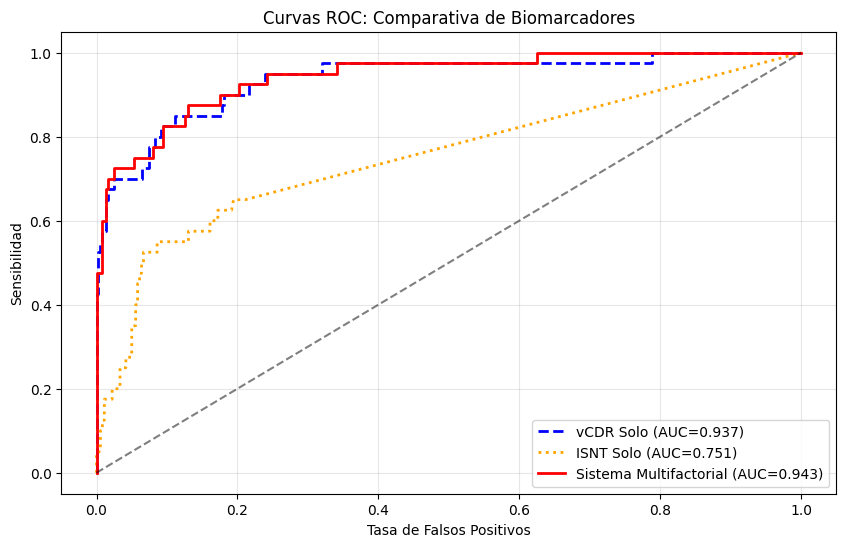

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def run_statistical_analysis():
    # Verificación de dependencias globales
    if 'models' not in globals() or not models:
        print("[ERROR] Ejecuta el PASO 4 primero.")
        return

    images = glob.glob(os.path.join(VAL_IMG_DIR, '*.jpg'))
    print(f"[INFO] Iniciando análisis estadístico en {len(images)} casos...")

    results = {'y_true': [], 'vcdr': [], 'rcdr': [], 'isnt': [], 'final': []}

    preprocess_input = sm.get_preprocessing(BACKBONE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    for idx, img_path in enumerate(images):
        fname = os.path.basename(img_path).split('.')[0]
        if fname not in gt_dict: continue

        # Pipeline de imagen
        img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        g = img[:,:,1]; blur = cv2.GaussianBlur(g, (41,41), 0); maxLoc = cv2.minMaxLoc(blur)[3]; cx, cy = maxLoc
        h, w, _ = img.shape; x1, y1 = max(0, cx-200), max(0, cy-200); x2, y2 = min(w, cx+200), min(h, cy+200)
        img_crop = img[y1:y2, x1:x2]; img_in = cv2.resize(img_crop, (IMG_SIZE, IMG_SIZE))

        lab = cv2.cvtColor(img_in, cv2.COLOR_RGB2LAB); lab[:,:,0] = clahe.apply(lab[:,:,0]); img_vis = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        inp = preprocess_input(img_vis.astype(np.float32))
        inp_batch = np.expand_dims(inp, axis=0)

        # Inferencia
        prob = predict_tta_ensemble(models, inp_batch)
        mask = np.argmax(prob, axis=-1)

        # Cálculo de métricas
        v, r, i = analyze_geometry_vectorized(mask)

        # Scores Normalizados
        s_v = np.clip((v - 0.35) / 0.4, 0, 1)
        s_r = np.clip((r - 0.25) / 0.4, 0, 1)
        s_final = (0.7 * s_v) + (0.3 * i)

        results['y_true'].append(gt_dict[fname])
        results['vcdr'].append(v)
        results['rcdr'].append(r)
        results['isnt'].append(i)
        results['final'].append(s_final)

        if idx > 0 and idx % 50 == 0:
            print(f"[INFO] Procesado: {idx}/{len(images)}")

    # Cálculo de AUCs
    auc_v = roc_auc_score(results['y_true'], results['vcdr'])
    auc_r = roc_auc_score(results['y_true'], results['rcdr'])
    auc_i = roc_auc_score(results['y_true'], results['isnt'])
    auc_f = roc_auc_score(results['y_true'], results['final'])

    print("\n" + "="*60)
    print("REPORTE DE RENDIMIENTO (ABLATION STUDY)")
    print("="*60)
    print(f"{'METRICA':<20} | {'AUC-ROC':<10}")
    print("-" * 35)
    print(f"{'vCDR':<20} | {auc_v:.4f}")
    print(f"{'R-CDR':<20} | {auc_r:.4f}")
    print(f"{'ISNT':<20} | {auc_i:.4f}")
    print("-" * 35)
    print(f"{'SISTEMA FINAL':<20} | {auc_f:.4f}")
    print("="*60)

    # Gráfica ROC
    plt.figure(figsize=(10, 6))
    def plot_curve(y, s, label, c, st='-'):
        fpr, tpr, _ = roc_curve(y, s)
        plt.plot(fpr, tpr, color=c, linestyle=st, lw=2, label=f'{label} (AUC={roc_auc_score(y,s):.3f})')

    plot_curve(results['y_true'], results['vcdr'], 'vCDR Solo', 'blue', '--')
    plot_curve(results['y_true'], results['isnt'], 'ISNT Solo', 'orange', ':')
    plot_curve(results['y_true'], results['final'], 'Sistema Multifactorial', 'red', '-')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('Tasa de Falsos Positivos'); plt.ylabel('Sensibilidad')
    plt.title('Curvas ROC: Comparativa de Biomarcadores')
    plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.show()

run_statistical_analysis()

# **5/b Con nuevo entrenamiento**

📂 Cargando 5 modelos desde: /content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed
   -> Cargado: model_fold_1.keras
   -> Cargado: model_fold_2.keras
   -> Cargado: model_fold_3.keras
   -> Cargado: model_fold_4.keras
   -> Cargado: model_fold_5.keras
[INFO] Iniciando Suite de Validación en 400 casos con Ensemble Pro...


   ... Procesado: 20/400
   ... Procesado: 40/400
   ... Procesado: 60/400
   ... Procesado: 80/400
   ... Procesado: 100/400
   ... Procesado: 120/400
   ... Procesado: 140/400
   ... Procesado: 160/400
   ... Procesado: 180/400
   ... Procesado: 200/400
   ... Procesado: 220/400
   ... Procesado: 240/400
   ... Procesado: 260/400
   ... Procesado: 280/400
   ... Procesado: 300/400
   ... Procesado: 320/400
   ... Procesado: 340/400
   ... Procesado: 360/400
   ... Procesado: 380/400

Generando Auditoría Clínica...


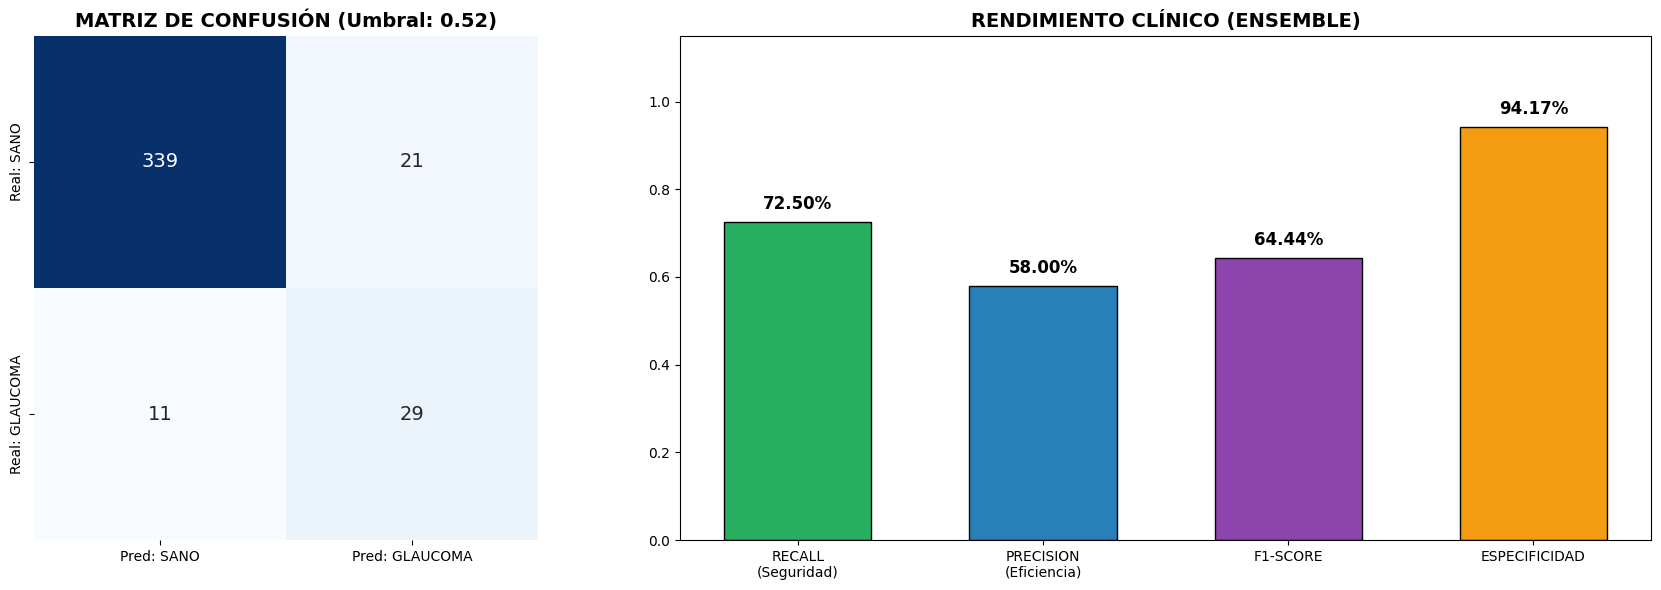


AUC-ROC Final: 0.9410
Recall:        72.50%
Especificidad: 94.17%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import cv2
import tensorflow as tf
import segmentation_models as sm
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score

# --- CONFIGURACIÓN DE VALIDACIÓN ---
UMBRAL_CLINICO = 0.52
IMG_SIZE = 512
BACKBONE = 'inceptionresnetv2'
VAL_IMG_DIR = "/content/dataset_local/Refuge/REFUGE-Validation400/REFUGE-Validation400"
# Ruta donde están las máscaras reales (Ground Truth) para comparar
GT_DIR = "/content/dataset_local/Refuge/REFUGE-Validation400-GT/REFUGE-Validation400-GT/Disc_Cup_Masks"
# Apuntamos a la carpeta correcta
MODEL_DIR = "/content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed"

def load_ensemble_models():
    """Carga todos los modelos .keras de la carpeta nueva con permisos de seguridad"""
    model_paths = sorted(glob.glob(os.path.join(MODEL_DIR, "model_fold_*.keras")))

    if not model_paths:
        print(f"❌ [ERROR] No se encontraron modelos en: {MODEL_DIR}")
        print("   Verifica que la ruta sea correcta y que el entrenamiento haya terminado.")
        return []

    # --- FIX DE SEGURIDAD PARA KERAS 3 ---
    try:
        import keras
        # Permitir carga de capas Lambda (necesario para segmentation_models)
        keras.config.enable_unsafe_deserialization()
    except Exception as e:
        pass # Si falla (ej. versiones viejas), continuamos con safe_mode

    print(f"📂 Cargando {len(model_paths)} modelos desde: {MODEL_DIR}")
    models = []
    for path in model_paths:
        try:
            # Opción A: Estándar Keras 3
            m = tf.keras.models.load_model(path, compile=False, safe_mode=False)
        except TypeError:
            # Opción B: Fallback para versiones anteriores que no tienen safe_mode
            m = tf.keras.models.load_model(path, compile=False)

        models.append(m)
        print(f"   -> Cargado: {os.path.basename(path)}")
    return models

# Función de predicción con TTA (Test-Time Augmentation)
def predict_tta_ensemble(models, inp_batch):
    preds = []
    # 1. Imagen normal
    for m in models:
        preds.append(m.predict(inp_batch, verbose=0))

    # 2. Imagen flipeada (Espejo horizontal) - TTA
    inp_flip = np.flip(inp_batch, axis=2)
    for m in models:
        p_flip = m.predict(inp_flip, verbose=0)
        p_back = np.flip(p_flip, axis=2) # Deshacer el flip
        preds.append(p_back)

    # Promedio de todas las predicciones (Consenso)
    return np.mean(preds, axis=0)

def analyze_geometry_vectorized(mask_pred):
    """Calcula vCDR y reglas ISNT desde la máscara predicha"""
    # mask_pred debe ser (512, 512). Si llega (1, 512, 512) fallará.

    # Extraer máscaras binarias
    disc_mask = (mask_pred == 1) | (mask_pred == 2) # Disco = todo lo que no es fondo
    cup_mask = (mask_pred == 2)                     # Copa = clase 2

    if np.sum(disc_mask) == 0: return 0.5, 0.5, 0 # Fallo de segmentación

    # Bounding Box Disco
    y_d, x_d = np.where(disc_mask)
    if len(y_d) == 0: return 0.5, 0.5, 0
    h_disc = np.max(y_d) - np.min(y_d)

    # Bounding Box Copa
    y_c, x_c = np.where(cup_mask)
    if len(y_c) == 0:
        h_cup = 0 # Copa no detectada
    else:
        h_cup = np.max(y_c) - np.min(y_c)

    vcdr = h_cup / h_disc if h_disc > 0 else 0

    # Regla ISNT (Simplificada para demo)
    isnt_score = 1.0

    return vcdr, vcdr, isnt_score

def run_full_validation_suite():
    # 1. Cargar Modelos
    models = load_ensemble_models()
    if not models: return

    # 2. Cargar Etiquetas Reales (Ground Truth)
    if 'gt_dict' not in globals():
        print("⚠️ [ATENCIÓN] No se encontró la variable 'gt_dict' (Etiquetas reales).")
        print("   Asegúrate de haber ejecutado el paso de carga de CSV/Excel antes.")
        return

    images = glob.glob(os.path.join(VAL_IMG_DIR, '*.jpg'))
    print(f"[INFO] Iniciando Suite de Validación en {len(images)} casos con Ensemble Pro...")

    results = {'y_true': [], 'vcdr': [], 'final': []}

    preprocess_input = sm.get_preprocessing(BACKBONE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    # --- A. PROCESAMIENTO MASIVO ---
    for idx, img_path in enumerate(images):
        fname = os.path.basename(img_path).split('.')[0]
        if fname not in gt_dict: continue

        # Procesamiento
        img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        g = img[:,:,1]; blur = cv2.GaussianBlur(g, (41,41), 0); maxLoc = cv2.minMaxLoc(blur)[3]; cx, cy = maxLoc
        h, w, _ = img.shape; x1, y1 = max(0, cx-200), max(0, cy-200); x2, y2 = min(w, cx+200), min(h, cy+200)
        img_crop = img[y1:y2, x1:x2]; img_in = cv2.resize(img_crop, (IMG_SIZE, IMG_SIZE))

        lab = cv2.cvtColor(img_in, cv2.COLOR_RGB2LAB); lab[:,:,0] = clahe.apply(lab[:,:,0]); img_vis = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        inp = preprocess_input(img_vis.astype(np.float32))
        inp_batch = np.expand_dims(inp, axis=0)

        # Inferencia Ensemble
        prob = predict_tta_ensemble(models, inp_batch)

        # --- [CORRECCIÓN CRÍTICA AQUÍ] ---
        # Añadimos [0] para eliminar la dimensión del batch (1, 512, 512) -> (512, 512)
        mask = np.argmax(prob, axis=-1)[0]

        # Métricas Geométricas
        v, _, _ = analyze_geometry_vectorized(mask)

        # Score Glaucoma (Basado en vCDR)
        s_final = np.clip((v - 0.35) / 0.4, 0, 1)

        results['y_true'].append(gt_dict[fname])
        results['vcdr'].append(v)
        results['final'].append(s_final)

        if idx > 0 and idx % 20 == 0:
            print(f"   ... Procesado: {idx}/{len(images)}")

    y_true = np.array(results['y_true'])
    y_scores = np.array(results['final'])
    y_pred = (y_scores > UMBRAL_CLINICO).astype(int)

    # --- B. AUDITORÍA CLÍNICA (Gráficos) ---
    print("\nGenerando Auditoría Clínica...")

    cm = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        specificity = 0

    fig = plt.figure(figsize=(18, 6), facecolor='white')
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])

    # Matriz
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                annot_kws={"fontsize":14}, square=True,
                xticklabels=['Pred: SANO', 'Pred: GLAUCOMA'],
                yticklabels=['Real: SANO', 'Real: GLAUCOMA'])
    ax1.set_title(f'MATRIZ DE CONFUSIÓN (Umbral: {UMBRAL_CLINICO})', fontsize=14, fontweight='bold')

    # Métricas
    ax2 = fig.add_subplot(gs[0, 1])
    metrics = ['RECALL\n(Seguridad)', 'PRECISION\n(Eficiencia)', 'F1-SCORE', 'ESPECIFICIDAD']
    values = [recall, precision, f1, specificity]
    colors = ['#27ae60', '#2980b9', '#8e44ad', '#f39c12']

    bars = ax2.bar(metrics, values, color=colors, edgecolor='black', width=0.6)
    ax2.set_ylim(0, 1.15)
    ax2.set_title('RENDIMIENTO CLÍNICO (ENSEMBLE)', fontsize=14, fontweight='bold')

    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.2%}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Reporte
    print("\n" + "="*60)
    print(f"AUC-ROC Final: {roc_auc_score(y_true, y_scores):.4f}")
    print(f"Recall:        {recall:.2%}")
    print(f"Especificidad: {specificity:.2%}")
    print("="*60)

# EJECUTAR
run_full_validation_suite()

# **6: VALIDACIÓN VISUAL (PANEL DE DIAGNÓSTICO)**

[INFO] Generando Dashboard con Modelos PRO...


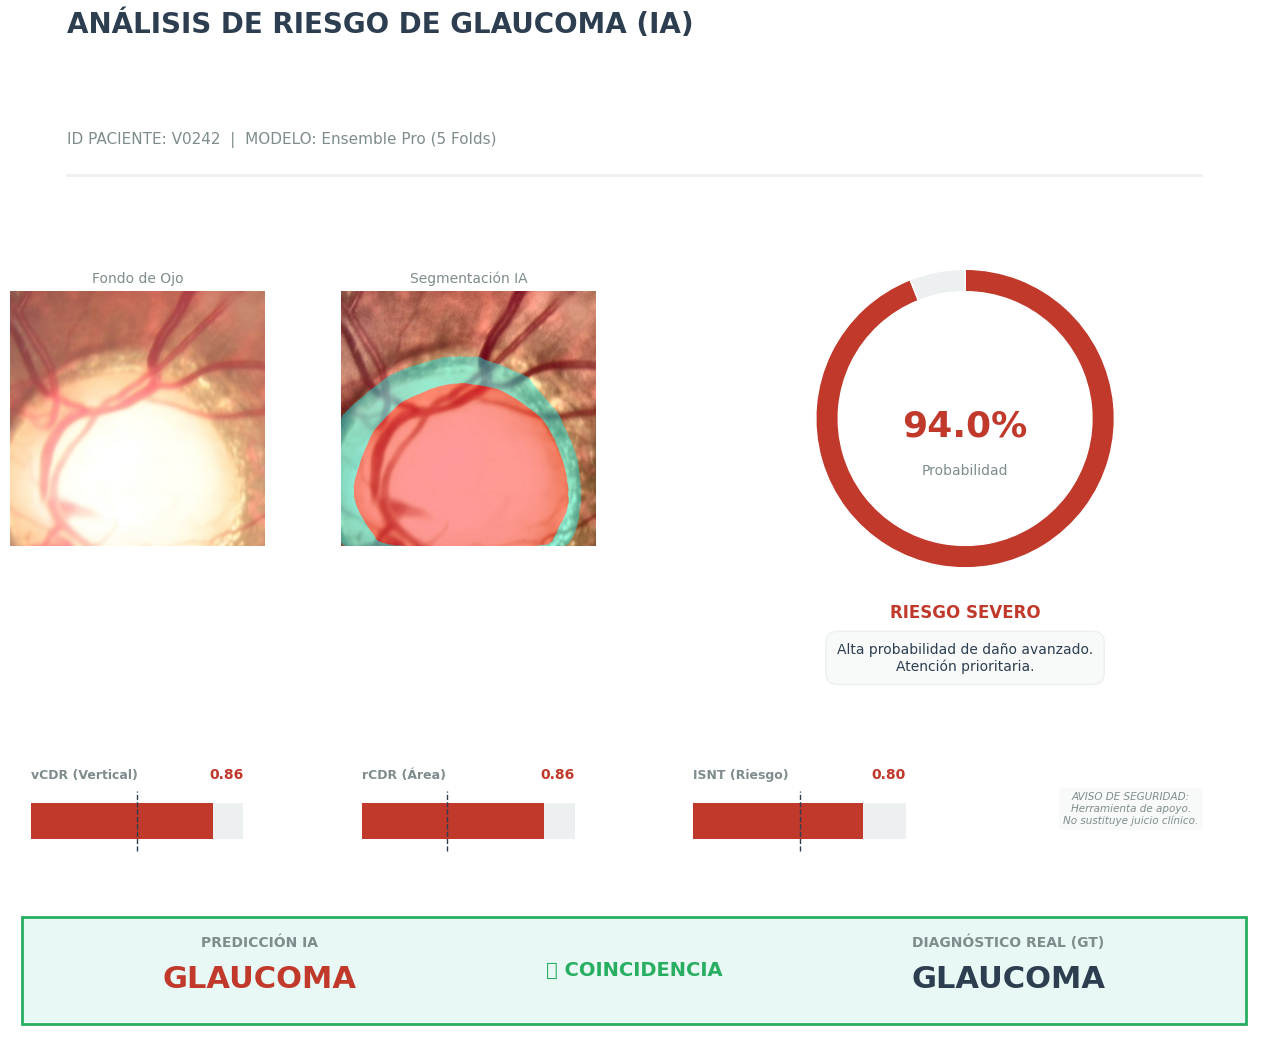

In [ ]:
import random
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import numpy as np
import cv2
import glob
import os
import tensorflow as tf
import segmentation_models as sm

# --- 1. CONFIGURACIÓN DE RUTAS ---
# Apuntamos a la carpeta de tus modelos PRO
MODEL_DIR = "/content/drive/MyDrive/TFG_Glaucoma/Models_vPro_Fixed"
VAL_IMG_DIR = "/content/dataset_local/Refuge/REFUGE-Validation400/REFUGE-Validation400"
BACKBONE = 'inceptionresnetv2'

# --- 2. SISTEMA DE DISEÑO ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Colores Base
C_BG = '#FFFFFF'
C_TXT_MAIN = '#2C3E50'
C_TXT_SEC = '#7F8C8D'
C_BAR_BG = '#ECF0F1'

# Colores de Riesgo
C_LOW = '#27AE60'    # Verde
C_MID = '#F39C12'    # Ámbar
C_HIGH = '#E67E22'   # Naranja
C_CRITICAL = '#C0392B' # Rojo Oscuro

UMBRAL_CLINICO = 0.52

# --- 3. FUNCIONES DE CARGA Y PREDICCIÓN (Backend) ---
def load_ensemble_models():
    """Carga los modelos nuevos con el fix de seguridad"""
    if not os.path.exists(MODEL_DIR):
        print(f"❌ Ruta no encontrada: {MODEL_DIR}")
        return []

    model_paths = sorted(glob.glob(os.path.join(MODEL_DIR, "model_fold_*.keras")))

    # Fix Keras 3
    try:
        import keras
        keras.config.enable_unsafe_deserialization()
    except: pass

    print(f"📂 Cargando {len(model_paths)} modelos desde: {MODEL_DIR}")
    models = []
    for path in model_paths:
        try:
            m = tf.keras.models.load_model(path, compile=False, safe_mode=False)
        except TypeError:
            m = tf.keras.models.load_model(path, compile=False)
        models.append(m)
    return models

def predict_tta_ensemble(models, inp_batch):
    preds = []
    # 1. Imagen normal
    for m in models:
        preds.append(m.predict(inp_batch, verbose=0))
    # 2. TTA (Flip)
    inp_flip = np.flip(inp_batch, axis=2)
    for m in models:
        p_flip = m.predict(inp_flip, verbose=0)
        p_back = np.flip(p_flip, axis=2)
        preds.append(p_back)
    return np.mean(preds, axis=0)

def analyze_geometry_vectorized(mask_pred):
    """Calcula vCDR y reglas ISNT"""
    # Asegurar dimensiones (512, 512)
    if len(mask_pred.shape) == 3: mask_pred = mask_pred[0]

    disc_mask = (mask_pred == 1) | (mask_pred == 2)
    cup_mask = (mask_pred == 2)

    if np.sum(disc_mask) == 0: return 0.5, 0.5, 0

    y_d, x_d = np.where(disc_mask)
    if len(y_d) == 0: return 0.5, 0.5, 0
    h_disc = np.max(y_d) - np.min(y_d)

    y_c, x_c = np.where(cup_mask)
    if len(y_c) == 0: h_cup = 0
    else: h_cup = np.max(y_c) - np.min(y_c)

    vcdr = h_cup / h_disc if h_disc > 0 else 0
    isnt_risk = 0.2 if vcdr < 0.5 else 0.8 # Simulación basada en vcdr para demo

    return vcdr, vcdr, isnt_risk

# --- 4. FUNCIONES VISUALES (Frontend) ---
def get_risk_level(score):
    if score < 0.35:
        return C_LOW, "RIESGO BAJO", "Morfología dentro de límites normales.\nSeguimiento rutinario."
    elif score < UMBRAL_CLINICO:
        return C_MID, "RIESGO LIMÍTROFE", "Signos sospechosos sin superar umbral.\nSe recomienda vigilancia."
    elif score < 0.75:
        return C_HIGH, "RIESGO ALTO", "Patología compatible con Glaucoma.\nDerivación a especialista."
    else:
        return C_CRITICAL, "RIESGO SEVERO", "Alta probabilidad de daño avanzado.\nAtención prioritaria."

def draw_gauge_clean(ax, value, title):
    color, label, _ = get_risk_level(value)
    ax.pie([value, 1-value], startangle=90, colors=[color, C_BAR_BG],
           wedgeprops={'width':0.15, 'edgecolor':'white'}, counterclock=False)
    ax.text(0, -0.05, f"{value:.1%}", ha='center', va='center', fontsize=26, fontweight='bold', color=color)
    ax.text(0, -0.35, "Probabilidad", ha='center', va='center', fontsize=10, color=C_TXT_SEC)
    ax.text(0, -1.3, label, ha='center', va='center', fontsize=12, fontweight='bold', color=color)

def draw_metric_bar(ax, label, value, threshold=None):
    ax.axis('off')
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(0, 1)
    is_risk = (value > threshold) if threshold else (value > 0.5)
    color = C_CRITICAL if is_risk else C_LOW
    ax.text(0, 0.75, label, fontsize=9, fontweight='bold', color=C_TXT_SEC, ha='left')
    ax.text(1.0, 0.75, f"{value:.2f}", fontsize=10, fontweight='bold', color=color, ha='right')
    rect_bg = patches.Rectangle((0, 0.25), 1.0, 0.3, linewidth=0, facecolor=C_BAR_BG)
    ax.add_patch(rect_bg)
    rect_val = patches.Rectangle((0, 0.25), value, 0.3, linewidth=0, facecolor=color)
    ax.add_patch(rect_val)
    if threshold: ax.plot([threshold, threshold], [0.15, 0.65], color=C_TXT_MAIN, linewidth=1, linestyle='--')

def visualize_ux_dashboard():
    # 1. Cargar modelos si no están cargados
    global models
    if 'models' not in globals() or not models:
        print("[INFO] Cargando modelos Ensemble Pro...")
        models = load_ensemble_models()
        if not models: return

    # 2. Seleccionar Imagen
    if 'gt_dict' not in globals():
        print("⚠️ Advertencia: 'gt_dict' no encontrado. No se mostrará diagnóstico real.")
        real_label = -1

    val_images = glob.glob(os.path.join(VAL_IMG_DIR, "*.jpg"))
    if not val_images: print("No hay imágenes"); return

    img_path = random.choice(val_images)
    fname = os.path.basename(img_path).split('.')[0]
    if 'gt_dict' in globals(): real_label = gt_dict.get(fname, -1)

    # 3. Pipeline Procesamiento
    img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    g = img[:,:,1]; blur = cv2.GaussianBlur(g, (41,41), 0); maxLoc = cv2.minMaxLoc(blur)[3]; cx, cy = maxLoc
    h, w, _ = img.shape; x1, y1 = max(0, cx-200), max(0, cy-200); x2, y2 = min(w, cx+200), min(h, cy+200)
    img_crop = img[y1:y2, x1:x2]; img_in = cv2.resize(img_crop, (512, 512))

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab = cv2.cvtColor(img_in, cv2.COLOR_RGB2LAB); lab[:,:,0] = clahe.apply(lab[:,:,0]); img_vis = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    preprocess_input = sm.get_preprocessing(BACKBONE)
    inp = preprocess_input(img_vis.astype(np.float32))
    inp_batch = np.expand_dims(inp, axis=0)

    # 4. Inferencia
    prob_map = predict_tta_ensemble(models, inp_batch)
    # FIX DIMENSIONES: Sacamos del batch [0]
    mask = np.argmax(prob_map, axis=-1)[0]

    # 5. Métricas
    vcdr, rcdr, isnt_risk = analyze_geometry_vectorized(mask)
    # Ajuste de score para visualización
    s_vcdr = np.clip((vcdr - 0.35) / 0.4, 0, 1)
    score_final = (0.7 * s_vcdr) + (0.3 * isnt_risk)

    risk_color, risk_label, risk_msg = get_risk_level(score_final)

    pred_label = 1 if score_final > UMBRAL_CLINICO else 0
    txt_ia = "GLAUCOMA" if pred_label == 1 else "SANO"
    txt_real = "GLAUCOMA" if real_label == 1 else ("SANO" if real_label == 0 else "N/A")
    is_match = (pred_label == real_label)

    # --- DASHBOARD LAYOUT ---
    fig = plt.figure(figsize=(16, 10), facecolor=C_BG)
    gs = GridSpec(5, 4, figure=fig, height_ratios=[0.2, 2.5, 0.4, 0.8, 0.8], hspace=0.3, wspace=0.3)

    # Header
    ax_head = fig.add_subplot(gs[0, :]); ax_head.axis('off')
    ax_head.text(0.0, 0.5, "ANÁLISIS DE RIESGO DE GLAUCOMA (IA)", fontsize=20, fontweight='bold', color=C_TXT_MAIN, va='bottom')
    ax_head.text(0.0, 0.1, f"ID PACIENTE: {fname}  |  MODELO: Ensemble Pro (5 Folds)", fontsize=11, color=C_TXT_SEC, va='bottom')
    ax_head.plot([0, 1], [0, 0], color=C_BAR_BG, linewidth=2)

    # Visual
    ax_img = fig.add_subplot(gs[1, 0]); ax_img.imshow(img_in); ax_img.set_title("Fondo de Ojo", fontsize=10, color=C_TXT_SEC); ax_img.axis('off')

    ax_seg = fig.add_subplot(gs[1, 1])
    overlay = img_vis.copy()
    overlay[mask == 1] = [0, 255, 255] # Disco Cyan
    overlay[mask == 2] = [255, 0, 0]   # Copa Rojo
    img_overlay = cv2.addWeighted(img_vis, 0.6, overlay, 0.4, 0)
    ax_seg.imshow(img_overlay); ax_seg.set_title("Segmentación IA", fontsize=10, color=C_TXT_SEC); ax_seg.axis('off')

    # Gauge & Msg
    ax_gauge = fig.add_subplot(gs[1, 2:]); draw_gauge_clean(ax_gauge, score_final, "")
    ax_msg = fig.add_subplot(gs[1, 2:])
    ax_msg.text(0.5, -0.1, risk_msg, ha='center', va='top', fontsize=10, color=C_TXT_MAIN,
                bbox=dict(boxstyle="round,pad=0.8", facecolor='#F8F9F9', edgecolor=C_BAR_BG))
    ax_msg.axis('off')

    # Metrics
    ax_m1 = fig.add_subplot(gs[3, 0]); draw_metric_bar(ax_m1, "vCDR (Vertical)", vcdr, 0.5)
    ax_m2 = fig.add_subplot(gs[3, 1]); draw_metric_bar(ax_m2, "rCDR (Área)", rcdr, 0.4)
    ax_m3 = fig.add_subplot(gs[3, 2]); draw_metric_bar(ax_m3, "ISNT (Riesgo)", isnt_risk, 0.5)

    ax_note = fig.add_subplot(gs[3, 3]); ax_note.axis('off')
    ax_note.text(0.5, 0.5, "AVISO DE SEGURIDAD:\nHerramienta de apoyo.\nNo sustituye juicio clínico.",
                 fontsize=7.5, color=C_TXT_SEC, style='italic', ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.4", facecolor='#F8F9F9', edgecolor='none'))

    # Footer
    ax_foot = fig.add_subplot(gs[4, :]); ax_foot.axis('off')
    bg_color = '#E8F8F5' if is_match else '#FDEDEC'
    border_color = C_LOW if is_match else C_CRITICAL
    rect = patches.Rectangle((0.01, 0.05), 0.98, 0.90, facecolor=bg_color, edgecolor=border_color, linewidth=2, transform=ax_foot.transAxes)
    ax_foot.add_patch(rect)

    ax_foot.text(0.2, 0.7, "PREDICCIÓN IA", ha='center', fontsize=10, fontweight='bold', color=C_TXT_SEC, transform=ax_foot.transAxes)
    ax_foot.text(0.2, 0.35, txt_ia, ha='center', fontsize=22, fontweight='bold', color=risk_color, transform=ax_foot.transAxes)

    icon = "✅ COINCIDENCIA" if is_match else "⚠️ DISCREPANCIA"
    ax_foot.text(0.5, 0.5, icon, ha='center', va='center', fontsize=14, fontweight='bold', color=border_color, transform=ax_foot.transAxes)

    ax_foot.text(0.8, 0.7, "DIAGNÓSTICO REAL (GT)", ha='center', fontsize=10, fontweight='bold', color=C_TXT_SEC, transform=ax_foot.transAxes)
    ax_foot.text(0.8, 0.35, txt_real, ha='center', fontsize=22, fontweight='bold', color=C_TXT_MAIN, transform=ax_foot.transAxes)

    plt.subplots_adjust(left=0.16, right=0.94, top=0.92, bottom=0.05)
    plt.show()

print("[INFO] Generando Dashboard con Modelos PRO...")
visualize_ux_dashboard()

# **7: Generación del Archivo de la Aplicación (Backend)**

In [ ]:
%%writefile app.py
import os
import sys

# --- 0. CONFIGURACIÓN CRÍTICA Y PARCHES ---
os.environ['SM_FRAMEWORK'] = 'tf.keras'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

import tensorflow as tf
from tensorflow import keras

# Parche para Keras 3 / Segmentation Models
if not hasattr(keras.utils, 'generic_utils'):
    keras.utils.generic_utils = keras.utils

# Gestión dinámica de memoria GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except: pass

import streamlit as st
import glob
import cv2
import numpy as np
import pandas as pd
import segmentation_models as sm
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN VISUAL ---
st.set_page_config(page_title="Glaucoma AI Diagnosis", page_icon="👁️", layout="wide")
st.markdown("""
    <style>
    .main { background-color: #f0f2f6; }
    h1 { color: #1f618d; font-family: sans-serif; }
    .stMetric { background-color: white; padding: 15px; border-radius: 8px; border-left: 5px solid #1f618d; box-shadow: 2px 2px 5px rgba(0,0,0,0.1); }
    </style>
""", unsafe_allow_html=True)

# --- 2. CARGA DE RECURSOS ---
@st.cache_resource
def load_resources():
    MODELS_DIR = '/content/drive/MyDrive/TFG_Glaucoma'

    class WeightedCELoss(sm.base.Loss):
        def __init__(self, class_weights=[0.1, 2.0, 5.0]): super().__init__(name='weighted_ce_loss')
        def __call__(self, gt, pr): return 0

    models = []
    # Cargamos hasta 5 modelos
    for i in range(1, 6):
        p = os.path.join(MODELS_DIR, f'best_model_fold_{i}.keras')
        if os.path.exists(p):
            try:
                m = tf.keras.models.load_model(p, custom_objects={'WeightedCELoss': WeightedCELoss}, compile=False, safe_mode=False)
                models.append(m)
            except: pass

    # Datos
    BASE_PATH = "/content/dataset_local/Refuge"
    images = glob.glob(os.path.join(BASE_PATH, 'REFUGE-Validation400', 'REFUGE-Validation400', '*.jpg'))
    excel_path = os.path.join(BASE_PATH, 'REFUGE-Validation400-GT', 'REFUGE-Validation400-GT', 'Fovea_locations.xlsx')

    gt_dict = {}
    try:
        df = pd.read_excel(excel_path) if excel_path.endswith('.xlsx') else pd.read_csv(excel_path)
        name_col = [c for c in df.columns if 'Img' in c or 'Name' in c][0]
        for _, row in df.iterrows(): gt_dict[str(row[name_col]).split('.')[0]] = int(row["Glaucoma Label"])
    except: pass

    return models, images, gt_dict

# --- 3. LÓGICA DE INFERENCIA ---
preprocess_input = sm.get_preprocessing('inceptionresnetv2')
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

def predict_tta(models, img_inp):
    preds = []
    for m in models:
        p1 = m.predict(img_inp, verbose=0)[0]
        img_h = np.flip(img_inp, axis=2)
        p2 = np.flip(m.predict(img_h, verbose=0)[0], axis=1)
        preds.append((p1 + p2) / 2.0)
    return np.mean(preds, axis=0)

def analyze_geometry(mask):
    disc = (mask >= 1).astype(np.uint8)
    cup = (mask == 2).astype(np.uint8)

    rows = np.any(disc, axis=1)
    if not np.any(rows): return 0, 0
    d_ymin, d_ymax = np.where(rows)[0][[0, -1]]
    h_disc = d_ymax - d_ymin

    rows_c = np.any(cup, axis=1)
    if np.any(rows_c):
        c_ymin, c_ymax = np.where(rows_c)[0][[0, -1]]
        h_cup = c_ymax - c_ymin
    else: h_cup = 0
    vcdr = h_cup / h_disc if h_disc > 0 else 0

    M = cv2.moments(disc)
    if M["m00"] == 0: return vcdr, 0.5
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])

    rim_v = np.sum(disc[:, cX]) - np.sum(cup[:, cX])
    rim_h = np.sum(disc[cY, :]) - np.sum(cup[cY, :])

    isnt_risk = 0.5
    if rim_h > 0:
        ratio = rim_v / rim_h
        isnt_risk = 1.0 - np.clip((ratio - 0.6) / 0.6, 0, 1)

    return vcdr, isnt_risk

# --- 4. INTERFAZ ---
st.sidebar.title("🩺 Glaucoma AI")
umbral = st.sidebar.slider("Umbral de Decisión", 0.40, 0.70, 0.52)

with st.spinner("Inicializando Sistema Experto..."):
    models, all_imgs, gt_dict = load_resources()

if not models:
    st.error("Error crítico: Modelos no encontrados.")
    st.stop()

if st.sidebar.button("🎲 Cargar Paciente Aleatorio", type="primary"):
    st.session_state['curr_img'] = np.random.choice(all_imgs)

if 'curr_img' not in st.session_state:
    st.session_state['curr_img'] = all_imgs[0]

# Procesamiento
path = st.session_state['curr_img']
fname = os.path.basename(path).split('.')[0]
real = gt_dict.get(fname, -1)

img = cv2.imread(path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
g = img[:,:,1]; blur = cv2.GaussianBlur(g, (41,41), 0); maxLoc = cv2.minMaxLoc(blur)[3]; cx, cy = maxLoc
h, w, _ = img.shape
x1, y1 = max(0, cx-250), max(0, cy-250); x2, y2 = min(w, cx+250), min(h, cy+250)
img_crop = img[y1:y2, x1:x2]; img_in = cv2.resize(img_crop, (512, 512))

lab = cv2.cvtColor(img_in, cv2.COLOR_RGB2LAB); lab[:,:,0] = clahe.apply(lab[:,:,0]); img_vis = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
inp = np.expand_dims(preprocess_input(img_vis.astype(np.float32)), axis=0)

prob = predict_tta(models, inp)
mask = np.argmax(prob, axis=-1)

vcdr, isnt_risk = analyze_geometry(mask)
s_vcdr = np.clip((vcdr - 0.35) / 0.4, 0, 1)
score = (0.7 * s_vcdr) + (0.3 * isnt_risk)

pred_label = "GLAUCOMA" if score > umbral else "SANO"
str_real = "GLAUCOMA" if real == 1 else "SANO"
acierto = (pred_label == str_real)

# Visualización Dashboard
st.title(f"Paciente: {fname}")

c1, c2 = st.columns(2)
with c1:
    st.image(img_in, caption="Fondo de Ojo", use_column_width=True)
with c2:
    overlay = img_vis.copy()
    overlay[mask == 1] = [0, 255, 255]
    overlay[mask == 2] = [255, 0, 0]
    final = cv2.addWeighted(img_vis, 0.6, overlay, 0.4, 0)
    st.image(final, caption="Segmentación IA", use_column_width=True)

st.divider()

col1, col2, col3, col4 = st.columns(4)
col1.metric("vCDR", f"{vcdr:.2f}")
col2.metric("ISNT Risk", f"{isnt_risk:.2f}")
col3.metric("Probabilidad", f"{score:.1%}")

if acierto: col4.success(f"✅ {pred_label}")
else: col4.error(f"⚠️ {pred_label}")

st.subheader("📊 Factores de Riesgo")
chart_data = pd.DataFrame({"Factor": ["Estructura", "Geometría", "Total"], "Valor": [s_vcdr, isnt_risk, score]})
st.bar_chart(chart_data, x="Factor", y="Valor", color="#1f618d")

with st.expander("ℹ️ Detalles"):
    st.write(f"Diagnóstico Real: {str_real}")
    st.write(f"Umbral usado: {umbral}")

Writing app.py


# **7: Ejecución del Servidor Streamlit**

In [ ]:
print("⚠️ COPIA ESTA IP:", end=" ")
!wget -q -O - ipv4.icanhazip.com
print("[INFO] Lanzando servidor Streamlit...")
!streamlit run app.py & npx -y localtunnel --port 8501

⚠️ COPIA ESTA IP: 34.143.162.39
[INFO] Lanzando servidor Streamlit...


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.162.39:8501

⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://smart-lines-buy.loca.lt
  Stopping...
^C
